In [2]:
# Week4 (Best, Jupyter/Script Friendly) — BTS On-Time
# End-to-end with progress bars, calibration, cost-based thresholds,
# reliability diagrams, ablations, SHAP (optional) and monthly backtest.
# Outputs: ./bts_on_time_data/eda/week4_*.*

# =========================
# CONFIG (edit as needed)
# =========================
ROOT_DIR   = "./bts_on_time_data"
SAMPLE_REL = "eda/sample_100k_week2_features.parquet"
SEED       = 42

# Classification settings
CALIB_METHOD   = "sigmoid"     # "sigmoid", "isotonic", or "none"
N_CAL_BINS     = 15
FP_COST        = 1.0
FN_COST        = 5.0

# HistGradientBoosting tuning (balanced for speed+quality)
HGB_TUNE_MODE  = "fast"        # "fast" (~16 combos) or "full" (heavier)
HGB_MAX_ITER   = 300           # uses early_stopping internally

# Optional extras (toggle for speed)
DO_ABLATION     = True         # feature group ablations (Ridge/LR)
DO_BACKTEST     = True         # month-by-month backtest
DO_RELIABILITY  = True         # reliability diagrams
SHAP_N          = 0            # set >0 (e.g., 200) to enable SHAP

# =========================
# Imports
# =========================
import json, warnings, sys, os
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    roc_auc_score, average_precision_score,
    precision_recall_curve, confusion_matrix,
    brier_score_loss
)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, HistGradientBoostingClassifier

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=FutureWarning, module=r"sklearn\.metrics\._regression")

# =========================
# Paths
# =========================
ROOT = Path(ROOT_DIR)
EDA  = ROOT/"eda"
EDA.mkdir(parents=True, exist_ok=True)
SAMPLE = ROOT/SAMPLE_REL

# =========================
# Utilities
# =========================
REQ_BASE_COLS = ["Year","Month","DayofMonth","FlightDate","Origin","Dest",
                 "ArrDelay","ArrDel15","Distance","CRSDepTime_min","dow","is_weekend",
                 "quarter","season","tod_bin"]

PROFILE_COLS = [
    "route_med_arr_delay","route_ontime_rate","route_flights",
    "carrier_med_arr_delay","carrier_ontime_rate","carrier_flights"
]
ROLL_COLS = [
    "route_on_7d","route_on_14d","route_on_30d","route_med_30d",
    "car_on_7d","car_on_14d","car_on_30d","car_med_30d",
    "orig_hour_load_7d","dest_hour_load_7d"
]

# RMSE helper (no deprecation warning)
try:
    from sklearn.metrics import root_mean_squared_error as _rmse
    def RMSE(y_true, y_pred): return float(_rmse(y_true, y_pred))
except Exception:
    from sklearn.metrics import mean_squared_error as _mse
    def RMSE(y_true, y_pred): return float(np.sqrt(_mse(y_true, y_pred)))

def ensure_datetime(df):
    if "FlightDate" in df.columns and not np.issubdtype(df["FlightDate"].dtype, np.datetime64):
        df["FlightDate"] = pd.to_datetime(df["FlightDate"])
    return df

def safe_carrier_col(df):
    for c in ["Reporting_Airline","IATA_CODE_Reporting_Airline","UniqueCarrier"]:
        if c in df.columns:
            return c
    raise KeyError("Carrier column not found.")

def safe_rate_on_time(s):
    a = pd.to_numeric(s, errors="coerce").to_numpy()
    a = a[~np.isnan(a)]
    if a.size == 0: return np.nan
    return 1.0 - a.mean()

def safe_median(s):
    a = pd.to_numeric(s, errors="coerce").to_numpy()
    a = a[~np.isnan(a)]
    return float(np.median(a)) if a.size else np.nan

def metrics_reg(y_true, y_pred):
    return {"MAE": float(mean_absolute_error(y_true, y_pred)),
            "RMSE": RMSE(y_true, y_pred),
            "R2": float(r2_score(y_true, y_pred))}

def choose_best_threshold_f1(y_true, y_score):
    ps, rs, ts = precision_recall_curve(y_true, y_score)[:3]
    f1s = 2 * (ps * rs) / (ps + rs + 1e-12)
    i = int(np.nanargmax(f1s))
    thr = float(ts[i-1]) if i > 0 else 0.5
    return thr, float(f1s[i]), float(ps[i]), float(rs[i])

def confusion_at(y_true, y_prob, thr):
    pred = (y_prob >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()
    return {"threshold": float(thr), "TP": int(tp), "FP": int(fp), "TN": int(tn), "FN": int(fn)}

def business_cost_at(y_true, y_prob, thr, fp_cost=1.0, fn_cost=5.0):
    cm = confusion_at(y_true, y_prob, thr)
    return fp_cost*cm["FP"] + fn_cost*cm["FN"], cm

def split_temporal(df):
    train = df[df["Year"] == 2024].copy()
    val   = df[(df["Year"] == 2025) & (df["Month"].isin([1,2,3]))].copy()
    test  = df[(df["Year"] == 2025) & (df["Month"] == 4)].copy()
    return train, val, test

def drop_na_target(df, ycol):
    return df[pd.notna(df[ycol])].copy()

# ---------- profiles (train-only, leakage-safe) ----------
def build_profiles_train(df_train, carrier_col):
    r = (df_train.groupby(["Origin","Dest"], dropna=False)
         .agg(route_med_arr_delay=("ArrDelay", safe_median),
              route_ontime_rate=("ArrDel15", safe_rate_on_time),
              route_flights=("ArrDel15", "count"))
         .reset_index())
    c = (df_train.groupby([carrier_col], dropna=False)
         .agg(carrier_med_arr_delay=("ArrDelay", safe_median),
              carrier_ontime_rate=("ArrDel15", safe_rate_on_time),
              carrier_flights=("ArrDel15", "count"))
         .reset_index())
    return r, c

def attach_profiles(df, route_prof, carrier_prof, carrier_col):
    out = df.drop(columns=[c for c in PROFILE_COLS if c in df.columns], errors="ignore")
    out = out.merge(route_prof, on=["Origin","Dest"], how="left")
    out = out.merge(carrier_prof, on=[carrier_col], how="left")
    # simple fill for profiles
    for c in PROFILE_COLS:
        if c in out.columns:
            out[c] = out[c].fillna(out[c].median())
    return out

# ---------- rolling/time-aware features ----------
def _on_rate(s: pd.Series) -> float:
    x = pd.to_numeric(s, errors="coerce").astype(float)
    m = x[np.isfinite(x)]
    if m.size == 0:
        return np.nan
    return 1.0 - float(m.mean())

def _daily_group(df, group_cols):
    g = (df.groupby(group_cols + ["FlightDate"], dropna=False)
           .agg(n=("ArrDel15","count"),
                ontime=("ArrDel15", _on_rate),
                med_arr=("ArrDelay","median"))
           .reset_index())
    return g.sort_values("FlightDate")

def _hour_bin(x):
    try:
        return int((float(x)//60)%24)
    except Exception:
        return np.nan

def _rolling_join(hist, target, group_cols, windows=(7,14,30), prefix="route_"):
    dg = _daily_group(hist, group_cols).set_index("FlightDate")
    out = target.copy()
    for w in windows:
        on_w = (dg.groupby(group_cols)["ontime"]
                  .rolling(window=f"{w}D", min_periods=1).mean()
                  .shift(1).reset_index()
                  .rename(columns={"ontime": f"{prefix}on_{w}d"}))
        med30 = (dg.groupby(group_cols)["med_arr"]
                   .rolling(window="30D", min_periods=1).median()
                   .shift(1).reset_index()
                   .rename(columns={"med_arr": f"{prefix}med_30d"}))
        merged = on_w.merge(med30, on=group_cols+["FlightDate"], how="outer")
        m = out[group_cols + ["FlightDate"]].merge(merged, on=group_cols+["FlightDate"], how="left")
        out[f"{prefix}on_{w}d"]  = m.get(f"{prefix}on_{w}d")
        out[f"{prefix}med_30d"] = m.get(f"{prefix}med_30d")
    return out

def _hourly_load(hist, target, col_place, prefix):
    dfh = hist.copy()
    dfh["hour"] = dfh["CRSDepTime_min"].apply(_hour_bin)
    grp = (dfh.groupby([col_place,"hour","FlightDate"], dropna=False)
              .size().reset_index(name="dep")).set_index("FlightDate")
    out = target.copy()
    out["hour"] = out["CRSDepTime_min"].apply(_hour_bin)
    roll = (grp.groupby([col_place,"hour"])["dep"]
              .rolling(window="7D", min_periods=1).mean()
              .shift(1).reset_index()
              .rename(columns={"dep": f"{prefix}_hour_load_7d"}))
    m = out[[col_place,"hour","FlightDate"]].merge(roll, on=[col_place,"hour","FlightDate"], how="left")
    out[f"{prefix}_hour_load_7d"] = m.get(f"{prefix}_hour_load_7d")
    return out.drop(columns=["hour"])

def build_timeaware_features(hist_df, target_df, carrier_col):
    out = _rolling_join(hist_df, target_df, ["Origin","Dest"], windows=(7,14,30), prefix="route_")
    out = _rolling_join(hist_df, out, [carrier_col], windows=(7,14,30), prefix="car_")
    out = _hourly_load(hist_df, out, "Origin", "orig")
    out = _hourly_load(hist_df, out, "Dest", "dest")
    for c in ROLL_COLS:
        if c in out.columns:
            out[c] = out[c].fillna(out[c].median())
    return out

# ---------- feature spaces ----------
def setup_feature_spaces(df, carrier_col):
    cat = [carrier_col, "Origin", "Dest", "tod_bin", "season"]
    num_core = ["Distance", "dow", "is_weekend", "quarter", "CRSDepTime_min"]
    num = num_core + PROFILE_COLS + ROLL_COLS
    num_reg = list(num)
    if "DepDelay" in df.columns: num_reg.append("DepDelay")
    if "TaxiOut"  in df.columns: num_reg.append("TaxiOut")
    num_clf = list(num)
    y_reg, y_clf = "ArrDelay", "ArrDel15"
    groups = {"CORE": num_core, "PROFILE": PROFILE_COLS, "ROLLING": ROLL_COLS}
    return (num_reg, cat, y_reg), (num_clf, cat, y_clf), groups

def build_preprocessor(num_cols, cat_cols):
    num_pipe = Pipeline([("imputer", SimpleImputer(strategy="median")),
                         ("scaler", StandardScaler())])
    try:
        ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)
    cat_pipe = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                         ("ohe", ohe)])
    return ColumnTransformer([("num", num_pipe, num_cols),
                              ("cat", cat_pipe, cat_cols)], remainder="drop")

def class_weights_vector(y, pos_w: float = 1.0) -> np.ndarray:
    y_arr = np.asarray(y)
    y_arr = pd.to_numeric(pd.Series(y_arr), errors="coerce").fillna(0).astype(int).to_numpy()
    w = np.ones_like(y_arr, dtype=float)
    w[y_arr == 1] = pos_w
    return w

# ---------- tuning HGB ----------
def tune_histgbdt(Xtrain, ytrain, Xval, yval, seed=42, mode="fast", max_iter=HGB_MAX_ITER):
    yt = pd.to_numeric(pd.Series(ytrain), errors="coerce").fillna(0).astype(int).to_numpy()
    yv = pd.to_numeric(pd.Series(yval),   errors="coerce").fillna(0).astype(int).to_numpy()
    p = np.mean(yt == 1)
    base_w = (1.0 / max(p, 1e-6)) / (1.0 / max(1 - p, 1e-6))

    if mode == "fast":
        depths = [None, 8]
        lrs    = [0.05, 0.1]
        leafs  = [31, 63]
        mults  = [1.0, 2.0]
    else:
        depths = [None, 8, 12]
        lrs    = [0.05, 0.1, 0.2]
        leafs  = [31, 63, 127]
        mults  = [1.0, 1.5, 2.0, 3.0]

    combos = [(d,lr,lf,m) for d in depths for lr in lrs for lf in leafs for m in mults]
    best = None
    for (depth, lr, leaf, mult) in tqdm(combos, desc="[TUNE] HGB grid", leave=False):
        pos_w = base_w * mult
        clf = HistGradientBoostingClassifier(
            max_depth=depth, learning_rate=lr, max_leaf_nodes=leaf,
            early_stopping=True, validation_fraction=0.15,
            max_iter=max_iter, n_iter_no_change=10,
            random_state=seed
        )
        sw = class_weights_vector(yt, pos_w=pos_w)
        clf.fit(Xtrain, yt, sample_weight=sw)
        prob = clf.predict_proba(Xval)[:,1]
        pra = average_precision_score(yv, prob)
        cand = (pra, depth, lr, leaf, pos_w, clf)
        if (best is None) or (pra > best[0]):
            best = cand

    pra, depth, lr, leaf, pos_w, best_clf = best
    return best_clf, {"PR_AUC_val": float(pra), "max_depth": depth, "lr": lr,
                      "max_leaf_nodes": leaf, "pos_w": float(pos_w), "mode": mode}

# ---------- plots ----------
def save_reliability_plot(y_true, y_prob, out_png: Path, n_bins=15, title="Reliability"):
    prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=n_bins, strategy="quantile")
    plt.figure()
    plt.plot([0,1],[0,1], "--")
    plt.plot(prob_pred, prob_true, "o-")
    plt.xlabel("Predicted probability"); plt.ylabel("Observed frequency")
    plt.title(title); plt.tight_layout()
    plt.savefig(out_png, dpi=120); plt.close()

def save_pr_curve(y_true, y_prob, out_png: Path, title="PR Curve"):
    p, r, _ = precision_recall_curve(y_true, y_prob)
    plt.figure()
    plt.plot(r, p)
    plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title(title)
    plt.tight_layout(); plt.savefig(out_png, dpi=120); plt.close()

# ---------- monthly backtest (fixed for NaNs) ----------
def monthly_backtest(predictor, num_cols, cat_cols, train_df, months_df, ycol, task, out_csv):
    """
    - Regression: drop NaN targets per month before scoring.
    - Classification: coerce y to {0,1}; features NaN handled by pipeline.
    """
    rows = []
    dfm = months_df.copy()
    if task == "clf":
        dfm[ycol] = pd.to_numeric(dfm[ycol], errors="coerce").fillna(0).astype(int)

    month_keys = sorted(dfm.groupby(["Year","Month"]).groups.keys())
    for (yy, mm) in tqdm(month_keys, desc="[BACKTEST]", leave=False):
        chunk = dfm[(dfm["Year"]==yy) & (dfm["Month"]==mm)]
        if len(chunk) < 50:
            continue

        if task == "reg":
            s = chunk.dropna(subset=[ycol]).copy()
            if s.empty:
                continue
            pred = predictor.predict(s[num_cols + cat_cols])
            y = pd.to_numeric(s[ycol], errors="coerce").to_numpy()
            pred = np.asarray(pred)
            mask = np.isfinite(y) & np.isfinite(pred)
            if mask.sum() == 0:
                continue
            y = y[mask]; pred = pred[mask]
            rows.append({"Year": int(yy), "Month": int(mm), "n": int(len(s)),
                         "RMSE": RMSE(y, pred),
                         "MAE": float(np.mean(np.abs(y-pred))),
                         "R2": float(1 - np.sum((y-pred)**2) /
                                    max(np.sum((y - y.mean())**2), 1e-12))})
        else:
            s = chunk.copy()
            s[ycol] = pd.to_numeric(s[ycol], errors="coerce").fillna(0).astype(int)
            prob = predictor.predict_proba(s[num_cols + cat_cols])[:, 1]
            rows.append({"Year": int(yy), "Month": int(mm), "n": int(len(s)),
                         "ROC_AUC": float(roc_auc_score(s[ycol], prob)),
                         "PR_AUC": float(average_precision_score(s[ycol], prob))})

    out = pd.DataFrame(rows).sort_values(["Year","Month"])
    out.to_csv(out_csv, index=False)
    return out

# =========================
# LOAD + SPLIT + FEATS
# =========================
print("[LOAD]", SAMPLE)
assert SAMPLE.exists(), f"Features parquet not found: {SAMPLE}"
df = pd.read_parquet(SAMPLE)
df = ensure_datetime(df)
missing = set(REQ_BASE_COLS) - set(df.columns)
assert not missing, f"Missing required columns: {sorted(missing)}"
carrier_col = safe_carrier_col(df)

print("[SPLIT] temporal: train(2024) / val(2025-01..03) / test(2025-04)")
train0, val0, test0 = split_temporal(df)

print("[FEATS] time-aware (rolling/leakage-safe) ...")
train = build_timeaware_features(train0, train0, carrier_col)
val   = build_timeaware_features(train0, val0,   carrier_col)
test  = build_timeaware_features(pd.concat([train0, val0], ignore_index=True), test0, carrier_col)

# train-only profiles + attach
rprof, cprof = build_profiles_train(train0, carrier_col)
train = attach_profiles(train, rprof, cprof, carrier_col)
val   = attach_profiles(val,   rprof, cprof, carrier_col)
test  = attach_profiles(test,  rprof, cprof, carrier_col)

# Clean NaN targets for regression
train = drop_na_target(train, "ArrDelay")
val   = drop_na_target(val,   "ArrDelay")
test  = drop_na_target(test,  "ArrDelay")

print(f"[SHAPE] train={len(train):d}  val={len(val):d}  test={len(test):d}")

# =========================
# FEATURE SPACES & PREP
# =========================
(Xr_num, X_cat, y_reg), (Xc_num, _, y_clf), GROUPS = setup_feature_spaces(train, carrier_col)
reg_prep = build_preprocessor(Xr_num, X_cat)
clf_prep = build_preprocessor(Xc_num, X_cat)

# =========================
# REGRESSION (Ridge / RF)
# =========================
print("\n[REG] training Ridge & RF ...")
reg_models = {
    "ridge": Pipeline([("prep", reg_prep), ("mdl", Ridge(alpha=10.0, random_state=SEED))]),
    "rf":    Pipeline([("prep", reg_prep),
                       ("mdl", RandomForestRegressor(n_estimators=400, random_state=SEED, n_jobs=-1))]),
}
reg_results = {}
for name, pipe in reg_models.items():
    pipe.fit(train[Xr_num + X_cat], train[y_reg])
    def eval_split(s):
        pred = pipe.predict(s[Xr_num + X_cat])
        return metrics_reg(s[y_reg], pred), pred
    m_val, _ = eval_split(val)
    m_test, yhat_test = eval_split(test)
    reg_results[name] = {"val": m_val, "test": m_test}
    pd.DataFrame({
        "FlightDate": test.get("FlightDate"),
        "Origin": test["Origin"], "Dest": test["Dest"],
        carrier_col: test[carrier_col],
        "y_true": test[y_reg], "y_pred": yhat_test
    }).to_csv(EDA/f"week4_reg_pred_{name}.csv", index=False)
    print(f"[REG] {name}  val={m_val}  test={m_test}")

# =========================
# CLASSIFICATION (LR / RF / tuned HGB)
# =========================
for s in (train, val, test):
    s[y_clf] = pd.to_numeric(s[y_clf], errors="coerce").fillna(0).astype(int)

print("\n[CLF] fitting LR & RF base pipelines ...")
base_lr = Pipeline([("prep", clf_prep),
                    ("mdl", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED))])
base_rf = Pipeline([("prep", clf_prep),
                    ("mdl", RandomForestClassifier(n_estimators=400, class_weight="balanced",
                                                   random_state=SEED, n_jobs=-1))])
base_lr.fit(train[Xc_num + X_cat], train[y_clf])
base_rf.fit(train[Xc_num + X_cat], train[y_clf])

# HGB tuning on transformed arrays
print("[CLF] tuning HistGradientBoosting (balanced for speed & quality) ...")
Xtr = clf_prep.transform(train[Xc_num + X_cat])
Xva = clf_prep.transform(val[Xc_num + X_cat])
Xte = clf_prep.transform(test[Xc_num + X_cat])
hgb_best, hgb_info = tune_histgbdt(Xtr, train[y_clf].values, Xva, val[y_clf].values,
                                   seed=SEED, mode=HGB_TUNE_MODE, max_iter=HGB_MAX_ITER)
print(f"[CLF] HGB tuned ({HGB_TUNE_MODE}) val PR_AUC={hgb_info['PR_AUC_val']:.3f} "
      f"params={{'max_depth': {hgb_info['max_depth']}, 'lr': {hgb_info['lr']}, "
      f"'max_leaf_nodes': {hgb_info['max_leaf_nodes']}, 'pos_w': {hgb_info['pos_w']:.3f}}}")

def save_pr_and_rel(y_true, prob, tag, calflag):
    save_pr_curve(y_true, prob, EDA/f"week4_clf_pr_{tag}_{calflag}.png",
                  title=f"PR — {tag} ({calflag})")
    if DO_RELIABILITY:
        save_reliability_plot(y_true, prob, EDA/f"week4_reliability_{tag}_{calflag}.png",
                              n_bins=N_CAL_BINS, title=f"Reliability — {tag} ({calflag})")

def eval_uncal(pipe, tag):
    prob_val = pipe.predict_proba(val[Xc_num + X_cat])[:,1]
    prob_test = pipe.predict_proba(test[Xc_num + X_cat])[:,1]
    res_val = {"ROC_AUC": float(roc_auc_score(val[y_clf], prob_val)),
               "PR_AUC": float(average_precision_score(val[y_clf], prob_val))}
    res_test = {"ROC_AUC": float(roc_auc_score(test[y_clf], prob_test)),
                "PR_AUC": float(average_precision_score(test[y_clf], prob_test))}
    # F1-best (on val) -> report test CM at that thr + @0.5
    thr, f1b, pb, rb = choose_best_threshold_f1(val[y_clf], prob_val)
    cm05 = confusion_at(test[y_clf], prob_test, 0.5)
    cmb  = confusion_at(test[y_clf], prob_test, thr)
    # business-cost optimal thr (on val) -> report test cost/CM
    thrs = np.linspace(0.01, 0.99, 199)
    costs = [business_cost_at(val[y_clf], prob_val, t, FP_COST, FN_COST)[0] for t in thrs]
    thr_cost = float(thrs[int(np.argmin(costs))])
    cost_test, cm_cost = business_cost_at(test[y_clf], prob_test, thr_cost, FP_COST, FN_COST)
    pd.DataFrame({"thr": thrs, "val_cost": costs}).to_csv(EDA/f"week4_cost_curve_{tag}_val.csv", index=False)
    # calibration quality
    brier = float(brier_score_loss(test[y_clf], prob_test))
    pd.DataFrame({"y_true": test[y_clf], "y_prob": prob_test}).to_csv(EDA/f"week4_clf_prob_{tag}_uncal.csv", index=False)
    save_pr_and_rel(test[y_clf], prob_test, tag, "uncal")
    return {
        "val": {"ROC_AUC": res_val["ROC_AUC"], "PR_AUC": res_val["PR_AUC"],
                "best_thr_f1": float(thr), "bestF1_val": float(f1b),
                "prec_val": float(pb), "rec_val": float(rb)},
        "test": {"ROC_AUC": res_test["ROC_AUC"], "PR_AUC": res_test["PR_AUC"],
                 "cm@0.5": cm05, "cm@bestF1(val)": cmb,
                 "brier": brier, "thr_cost": thr_cost, "cost_test": float(cost_test),
                 "FP_cost": float(FP_COST), "FN_cost": float(FN_COST), "cm@thr_cost": cm_cost}
    }, prob_test

print("[CLF] evaluating uncalibrated models ...")
lr_uncal, _ = eval_uncal(base_lr, "logreg")
rf_uncal, _ = eval_uncal(base_rf, "rf")

# HGB (uncalibrated)
prob_val_hgb = hgb_best.predict_proba(Xva)[:,1]
prob_test_hgb = hgb_best.predict_proba(Xte)[:,1]
hgb_unc_val = {"ROC_AUC": float(roc_auc_score(val[y_clf], prob_val_hgb)),
               "PR_AUC": float(average_precision_score(val[y_clf], prob_val_hgb))}
hgb_unc_test = {"ROC_AUC": float(roc_auc_score(test[y_clf], prob_test_hgb)),
                "PR_AUC": float(average_precision_score(test[y_clf], prob_test_hgb))}
thr_h, f1b_h, pb_h, rb_h = choose_best_threshold_f1(val[y_clf], prob_val_hgb)
cm05_h = confusion_at(test[y_clf], prob_test_hgb, 0.5)
cmb_h  = confusion_at(test[y_clf], prob_test_hgb, thr_h)
thrs = np.linspace(0.01, 0.99, 199)
costs = [business_cost_at(val[y_clf], prob_val_hgb, t, FP_COST, FN_COST)[0] for t in thrs]
thr_cost_h = float(thrs[int(np.argmin(costs))])
cost_test_h, cm_cost_h = business_cost_at(test[y_clf], prob_test_hgb, thr_cost_h, FP_COST, FN_COST)
pd.DataFrame({"thr": thrs, "val_cost": costs}).to_csv(EDA/"week4_cost_curve_hgb_val.csv", index=False)
brier_hgb = float(brier_score_loss(test[y_clf], prob_test_hgb))
pd.DataFrame({"y_true": test[y_clf], "y_prob": prob_test_hgb}).to_csv(EDA/"week4_clf_prob_hgb_uncal.csv", index=False)
save_pr_and_rel(test[y_clf], prob_test_hgb, "hgb", "uncal")

clf_results = {
    "logreg": {"uncalibrated": lr_uncal},
    "rf":     {"uncalibrated": rf_uncal},
    "hgb":    {"uncalibrated": {
        "val": {"ROC_AUC": hgb_unc_val["ROC_AUC"], "PR_AUC": hgb_unc_val["PR_AUC"],
                "best_thr_f1": float(thr_h), "bestF1_val": float(f1b_h),
                "prec_val": float(pb_h), "rec_val": float(rb_h)},
        "test": {"ROC_AUC": hgb_unc_test["ROC_AUC"], "PR_AUC": hgb_unc_test["PR_AUC"],
                 "cm@0.5": cm05_h, "cm@bestF1(val)": cmb_h,
                 "brier": brier_hgb, "thr_cost": thr_cost_h, "cost_test": float(cost_test_h),
                 "FP_cost": float(FP_COST), "FN_cost": float(FN_COST), "cm@thr_cost": cm_cost_h}
    }}
}

# Calibration (fit on val -> report on test)
if CALIB_METHOD != "none":
    print(f"[CAL] applying calibration = {CALIB_METHOD} ...")
    def calibrate_and_eval(pipe, tag):
        base = pipe.named_steps["mdl"]
        Xv = pipe.named_steps["prep"].transform(val[Xc_num + X_cat])
        Xt = pipe.named_steps["prep"].transform(test[Xc_num + X_cat])
        try:
            calib = CalibratedClassifierCV(estimator=base, method=CALIB_METHOD, cv="prefit")
        except TypeError:
            calib = CalibratedClassifierCV(base_estimator=base, method=CALIB_METHOD, cv="prefit")
        calib.fit(Xv, val[y_clf])
        ptest = calib.predict_proba(Xt)[:,1]
        roc = float(roc_auc_score(test[y_clf], ptest))
        pr  = float(average_precision_score(test[y_clf], ptest))
        brier = float(brier_score_loss(test[y_clf], ptest))
        pd.DataFrame({"y_true": test[y_clf], "y_prob": ptest}).to_csv(EDA/f"week4_clf_prob_{tag}_cal.csv", index=False)
        save_pr_and_rel(test[y_clf], ptest, tag, "cal")
        return {"ROC_AUC": roc, "PR_AUC": pr, "brier": brier}

    clf_results["logreg"]["calibrated"] = {"val": clf_results["logreg"]["uncalibrated"]["val"],
                                           "test": calibrate_and_eval(base_lr, "logreg")}
    clf_results["rf"]["calibrated"] = {"val": clf_results["rf"]["uncalibrated"]["val"],
                                       "test": calibrate_and_eval(base_rf, "rf")}

    calib_hgb = CalibratedClassifierCV(estimator=hgb_best, method=CALIB_METHOD, cv="prefit")
    calib_hgb.fit(Xva, val[y_clf])
    ptest_hgb = calib_hgb.predict_proba(Xte)[:,1]
    roc = float(roc_auc_score(test[y_clf], ptest_hgb))
    pr  = float(average_precision_score(test[y_clf], ptest_hgb))
    brier = float(brier_score_loss(test[y_clf], ptest_hgb))
    pd.DataFrame({"y_true": test[y_clf], "y_prob": ptest_hgb}).to_csv(EDA/"week4_clf_prob_hgb_cal.csv", index=False)
    save_pr_and_rel(test[y_clf], ptest_hgb, "hgb", "cal")
    clf_results["hgb"]["calibrated"] = {"val": clf_results["hgb"]["uncalibrated"]["val"],
                                        "test": {"ROC_AUC": roc, "PR_AUC": pr, "brier": brier}}

# =========================
# ABLATION (lightweight)
# =========================
if DO_ABLATION:
    print("[ABLATION] running feature group removals (Ridge & LR) ...")
    rows = []
    # REG: Ridge
    for removed in tqdm([(), ("CORE",), ("PROFILE",), ("ROLLING",)], desc="[ABL] REG", leave=False):
        num_cols = [c for c in Xr_num if all(c not in GROUPS[g] for g in removed)]
        pipe = Pipeline([("prep", build_preprocessor(num_cols, X_cat)),
                         ("mdl", Ridge(alpha=10.0, random_state=SEED))])
        pipe.fit(train[num_cols + X_cat], train[y_reg])
        def ev(s):
            pred = pipe.predict(s[num_cols + X_cat]); m = metrics_reg(s[y_reg], pred); return m
        mv, mt = ev(val), ev(test)
        rows.append({"task":"reg","removed":"+".join(removed) if removed else "(none)",
                     "val_RMSE": mv["RMSE"], "test_RMSE": mt["RMSE"], "val_R2": mv["R2"], "test_R2": mt["R2"]})
    pd.DataFrame(rows).to_csv(EDA/"week4_ablation_reg.csv", index=False)

    # CLF: LR
    rows = []
    for removed in tqdm([(), ("CORE",), ("PROFILE",), ("ROLLING",)], desc="[ABL] CLF", leave=False):
        num_cols = [c for c in Xc_num if all(c not in GROUPS[g] for g in removed)]
        pipe = Pipeline([("prep", build_preprocessor(num_cols, X_cat)),
                         ("mdl", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED))])
        pipe.fit(train[num_cols + X_cat], train[y_clf])
        def ev(s):
            p = pipe.predict_proba(s[num_cols + X_cat])[:,1]
            return {"ROC_AUC": roc_auc_score(s[y_clf], p),
                    "PR_AUC": average_precision_score(s[y_clf], p)}
        mv, mt = ev(val), ev(test)
        rows.append({"task":"clf","removed":"+".join(removed) if removed else "(none)",
                     "val_ROC_AUC": mv["ROC_AUC"], "test_ROC_AUC": mt["ROC_AUC"],
                     "val_PR_AUC": mv["PR_AUC"], "test_PR_AUC": mt["PR_AUC"]})
    pd.DataFrame(rows).to_csv(EDA/"week4_ablation_clf.csv", index=False)
    print("[ABLATION] saved CSVs.")

# =========================
# SHAP (optional, default OFF)
# =========================
if SHAP_N > 0:
    print(f"[SHAP] explaining RF (clf) & RF (reg) on {SHAP_N} samples ...")
    try:
        import shap
        # CLF RF
        rf_clf = RandomForestClassifier(n_estimators=300, class_weight="balanced",
                                        random_state=SEED, n_jobs=-1)
        Xtr_shap = clf_prep.transform(train[Xc_num + X_cat])
        rf_clf.fit(Xtr_shap, train[y_clf])
        Xs = clf_prep.transform(test[Xc_num + X_cat])[:SHAP_N]
        expl1 = shap.TreeExplainer(rf_clf)
        sv1 = expl1.shap_values(Xs)
        plt.figure(); shap.summary_plot(sv1, Xs, show=False)
        plt.title("SHAP — RF Classifier"); plt.tight_layout()
        plt.savefig(EDA/"week4_shap_rf_clf_summary.png", dpi=140); plt.close()

        # REG RF
        rf_reg = RandomForestRegressor(n_estimators=300, random_state=SEED, n_jobs=-1)
        Xr_prep = reg_prep.transform(train[Xr_num + X_cat])
        rf_reg.fit(Xr_prep, train[y_reg])
        Xs2 = reg_prep.transform(test[Xr_num + X_cat])[:SHAP_N]
        expl2 = shap.TreeExplainer(rf_reg)
        sv2 = expl2.shap_values(Xs2)
        plt.figure(); shap.summary_plot(sv2, Xs2, show=False)
        plt.title("SHAP — RF Regressor"); plt.tight_layout()
        plt.savefig(EDA/"week4_shap_rf_reg_summary.png", dpi=140); plt.close()
        print("[SHAP] done.")
    except Exception as e:
        print(f"[SHAP] skipped ({e})")

# =========================
# BACKTEST (months)
# =========================
if DO_BACKTEST:
    print("[BACKTEST] month-by-month (Ridge & LR) ...")
    months_pool = pd.concat([val.copy(), test.copy()], ignore_index=True)  # 2025-01..04
    late_2024 = df[(df["Year"] == 2024) & (df["Month"].isin([9,10,11,12]))].copy()
    if not late_2024.empty:
        late_2024 = build_timeaware_features(train0, late_2024, carrier_col)
        late_2024 = attach_profiles(late_2024, rprof, cprof, carrier_col)
        months_pool = pd.concat([late_2024, months_pool], ignore_index=True)

    ridge_predictor = reg_models["ridge"]
    lr_predictor    = base_lr

    _ = monthly_backtest(ridge_predictor, Xr_num, X_cat, train, months_pool, y_reg, "reg", EDA/"week4_backtest_reg.csv")
    _ = monthly_backtest(lr_predictor,   Xc_num, X_cat, train, months_pool, y_clf, "clf", EDA/"week4_backtest_clf.csv")
    print("[BACKTEST] saved CSVs.")

# =========================
# SAVE MASTER JSON & SUMMARY
# =========================
summary = {
    "regression": reg_results,
    "classification": clf_results,
    "hgb_tuning": hgb_info,
    "calibration": CALIB_METHOD,
    "costs": {"FP_cost": float(FP_COST), "FN_cost": float(FN_COST)},
    "brier_defined": True,
    "features": {"groups": GROUPS, "rolling_added": ROLL_COLS},
    "ablation": {"reg_csv": str((EDA/"week4_ablation_reg.csv")) if DO_ABLATION else None,
                 "clf_csv": str((EDA/"week4_ablation_clf.csv")) if DO_ABLATION else None},
    "shap": {"rf_clf_summary_png": str(EDA/"week4_shap_rf_clf_summary.png") if (SHAP_N>0) else None,
             "rf_reg_summary_png": str(EDA/"week4_shap_rf_reg_summary.png") if (SHAP_N>0) else None},
    "backtest": {"reg_csv": str((EDA/"week4_backtest_reg.csv")) if DO_BACKTEST else None,
                 "clf_csv": str((EDA/"week4_backtest_clf.csv")) if DO_BACKTEST else None}
}
with open(EDA/"week4_metrics.json", "w") as f:
    json.dump(summary, f, indent=2)
print(f"\n[DONE] metrics json -> {EDA/'week4_metrics.json'}")

# Console digest
def fmt3(x): 
    try: return f"{float(x):.3f}"
    except: return x

print("\n=== Week4 — Regression (TEST) ===")
for k, v in reg_results.items():
    m = v["test"]
    print(f"{k:>6s} :: RMSE={fmt3(m['RMSE'])}  MAE={fmt3(m['MAE'])}  R2={fmt3(m['R2'])}")

print("\n=== Week4 — Classification (VAL/TEST, UNCAL) ===")
for tag, pack in {"logreg": lr_uncal, "rf": rf_uncal,
                  "hgb": {"val": hgb_unc_val, "test": hgb_unc_test}}.items():
    print(f"[{tag}]  val ROC={fmt3(pack['val']['ROC_AUC'])} PR={fmt3(pack['val']['PR_AUC'])}  "
          f"test ROC={fmt3(pack['test']['ROC_AUC'])} PR={fmt3(pack['test']['PR_AUC'])}")

if CALIB_METHOD != "none":
    print("\n=== Week4 — Classification (TEST, CAL) ===")
    for tag in ("logreg","rf","hgb"):
        if "calibrated" in clf_results.get(tag, {}):
            t = clf_results[tag]["calibrated"]["test"]
            print(f"[{tag}] ROC={fmt3(t['ROC_AUC'])} PR={fmt3(t['PR_AUC'])}  Brier={fmt3(t.get('brier',''))}")

# Positive rate on Week2 splits (context)
feats_p = EDA/"sample_100k_week2_features.parquet"
if feats_p.exists():
    feats = pd.read_parquet(feats_p)
    m_train = (feats["Year"]==2024)
    m_val   = (feats["Year"]==2025)&(feats["Month"].isin([1,2,3]))
    m_test  = (feats["Year"]==2025)&(feats["Month"]==4)
    def rate(msk):
        s = pd.to_numeric(feats.loc[msk, "ArrDel15"], errors="coerce")
        return (s==1).mean()
    print("\n=== Positive rate (Week2 splits) ===")
    print(f"train={rate(m_train):.3f}  val={rate(m_val):.3f}  test={rate(m_test):.3f}")

# List artifacts
arts = sorted([p.name for p in EDA.glob("week4_*")])
print("\n=== Week4 Artifacts under ./bts_on_time_data/eda ===")
for n in arts: print(" -", n)

[LOAD] bts_on_time_data/eda/sample_100k_week2_features.parquet
[SPLIT] temporal: train(2024) / val(2025-01..03) / test(2025-04)
[FEATS] time-aware (rolling/leakage-safe) ...
[SHAPE] train=66630  val=23694  test=8268

[REG] training Ridge & RF ...
[REG] ridge  val={'MAE': 8.191237672989818, 'RMSE': 11.395163177433242, 'R2': 0.9609170943405244}  test={'MAE': 7.744200214572428, 'RMSE': 11.055559485092555, 'R2': 0.9555342074264159}
[REG] rf  val={'MAE': 8.798130824761744, 'RMSE': 12.328272466251475, 'R2': 0.9542543086570416}  test={'MAE': 8.286566380422514, 'RMSE': 11.74101939502366, 'R2': 0.9498493926034124}

[CLF] fitting LR & RF base pipelines ...
[CLF] tuning HistGradientBoosting (balanced for speed & quality) ...


[TUNE] HGB grid:   0%|          | 0/16 [00:00<?, ?it/s]

[CLF] HGB tuned (fast) val PR_AUC=0.239 params={'max_depth': 8, 'lr': 0.05, 'max_leaf_nodes': 63, 'pos_w': 4.540}
[CLF] evaluating uncalibrated models ...
[CAL] applying calibration = sigmoid ...
[ABLATION] running feature group removals (Ridge & LR) ...


[ABL] REG:   0%|          | 0/4 [00:00<?, ?it/s]

[ABL] CLF:   0%|          | 0/4 [00:00<?, ?it/s]

[ABLATION] saved CSVs.
[BACKTEST] month-by-month (Ridge & LR) ...


[BACKTEST]:   0%|          | 0/8 [00:00<?, ?it/s]

[BACKTEST]:   0%|          | 0/8 [00:00<?, ?it/s]

[BACKTEST] saved CSVs.

[DONE] metrics json -> bts_on_time_data/eda/week4_metrics.json

=== Week4 — Regression (TEST) ===
 ridge :: RMSE=11.056  MAE=7.744  R2=0.956
    rf :: RMSE=11.741  MAE=8.287  R2=0.950

=== Week4 — Classification (VAL/TEST, UNCAL) ===
[logreg]  val ROC=0.561 PR=0.231  test ROC=0.582 PR=0.241
[rf]  val ROC=0.570 PR=0.239  test ROC=0.589 PR=0.247
[hgb]  val ROC=0.569 PR=0.239  test ROC=0.589 PR=0.247

=== Week4 — Classification (TEST, CAL) ===
[logreg] ROC=0.582 PR=0.241  Brier=0.157
[rf] ROC=0.589 PR=0.247  Brier=0.156
[hgb] ROC=0.589 PR=0.247  Brier=0.157

=== Positive rate (Week2 splits) ===
train=0.178  val=0.195  test=0.195

=== Week4 Artifacts under ./bts_on_time_data/eda ===
 - week4_ablation_clf.csv
 - week4_ablation_reg.csv
 - week4_backtest_clf.csv
 - week4_backtest_reg.csv
 - week4_clf_pr_hgb_cal.png
 - week4_clf_pr_hgb_uncal.png
 - week4_clf_pr_logreg_cal.png
 - week4_clf_pr_logreg_uncal.png
 - week4_clf_pr_rf_cal.png
 - week4_clf_pr_rf_uncal.png
 - wee

## Week4 — Summary

### Regression metrics

,Model,Split,MAE,RMSE,R2
0,ridge,val,8.191,11.395,0.9609
1,ridge,test,7.744,11.056,0.9555
2,rf,val,8.798,12.328,0.9543
3,rf,test,8.287,11.741,0.9498


### Classification — Uncalibrated

,Model,Split,ROC_AUC,PR_AUC,Brier,Thr_cost,Cost@thr
0,logreg,val,0.561,0.231,nan,nan,nan
1,logreg,test,0.582,0.241,0.255,0.347,6255.000
2,rf,val,0.570,0.239,nan,nan,nan
3,rf,test,0.589,0.247,0.165,0.059,6368.000
4,hgb,val,0.569,0.239,nan,nan,nan
5,hgb,test,0.589,0.247,0.254,0.416,6224.000


...

,Model,ROC_AUC,PR_AUC,Brier
0,logreg,0.582,0.241,0.157
1,rf,0.589,0.247,0.156
2,hgb,0.589,0.247,0.157


### Test confusion matrices (UNCAL)

,Model,Thr,TP,FP,TN,FN,F1,Precision,Recall
0,logreg,0.5,881,2732,3904,751,0.336,0.244,0.540
1,logreg,0.347,1281,4500,2136,351,0.346,0.222,0.785
2,rf,0.5,82,203,6433,1550,0.086,0.288,0.050
3,rf,0.059,1442,5418,1218,190,0.340,0.210,0.884
4,hgb,0.5,972,3007,3629,660,0.346,0.244,0.596
5,hgb,0.416,1197,4049,2587,435,0.348,0.228,0.733


### PR curves & Reliability diagrams

**PR — logreg (uncal)**

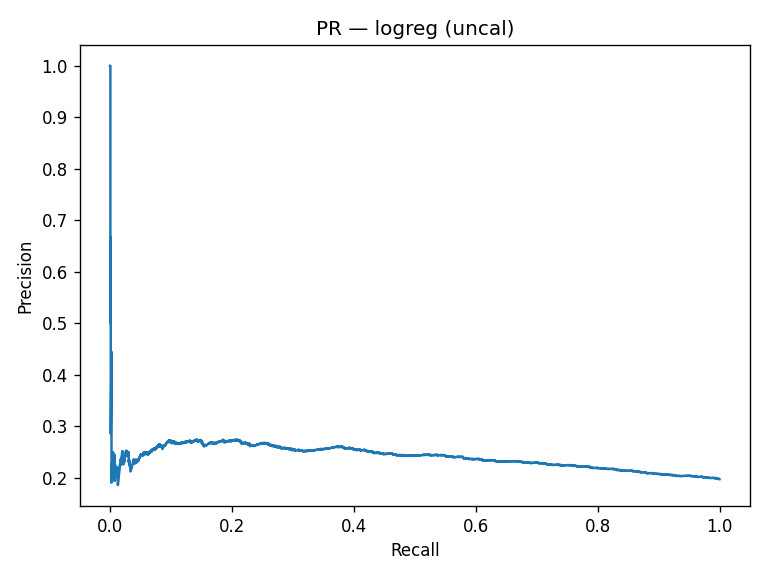

**Reliability — logreg (uncal)**

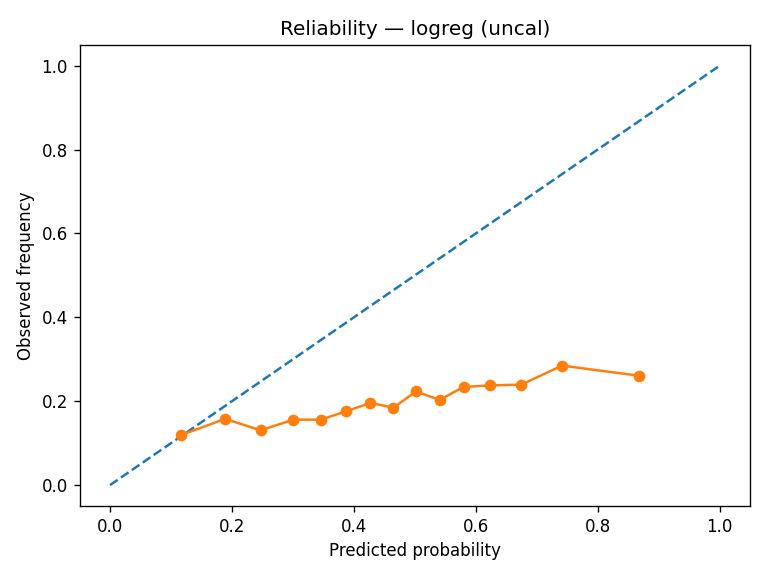

**PR — logreg (cal)**

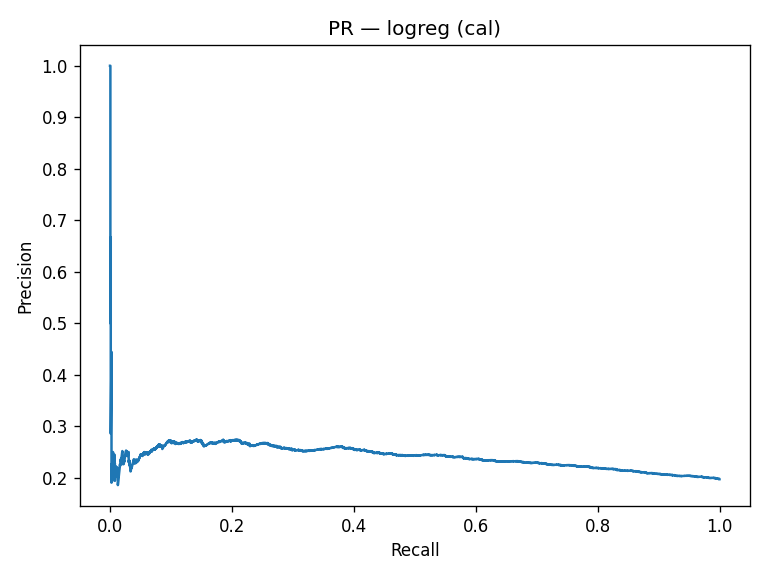

**Reliability — logreg (cal)**

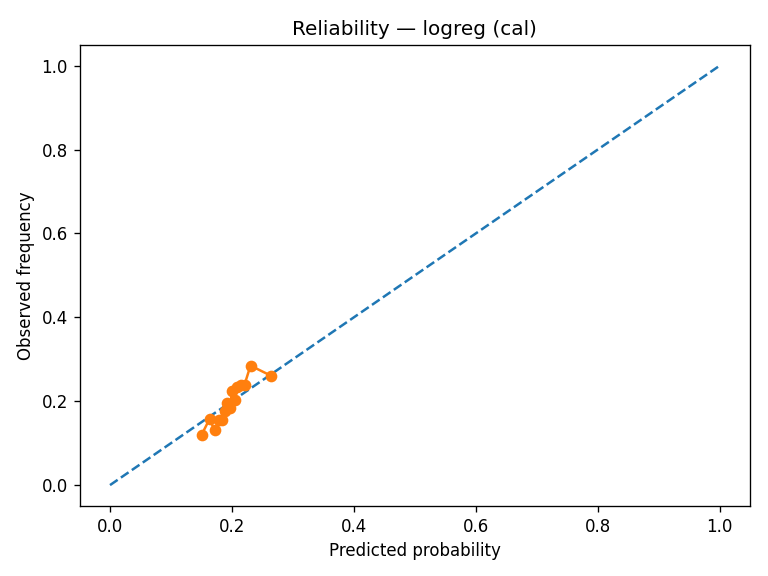

**PR — rf (uncal)**

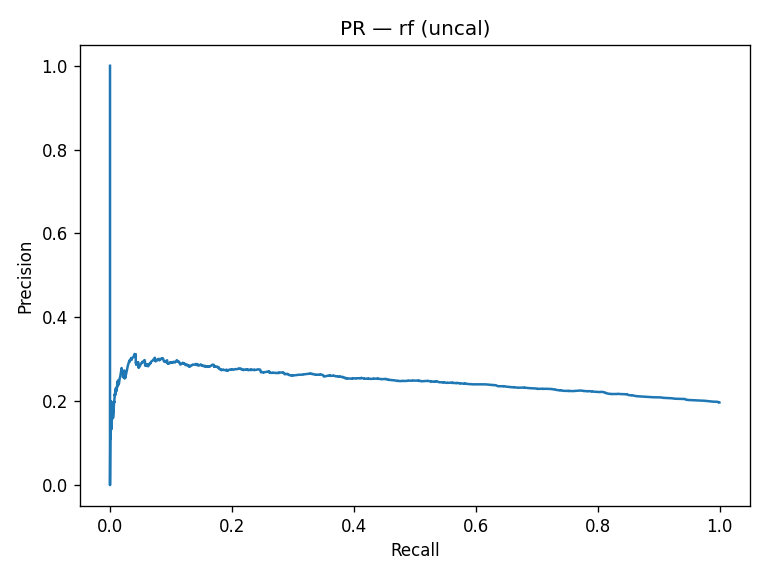

**Reliability — rf (uncal)**

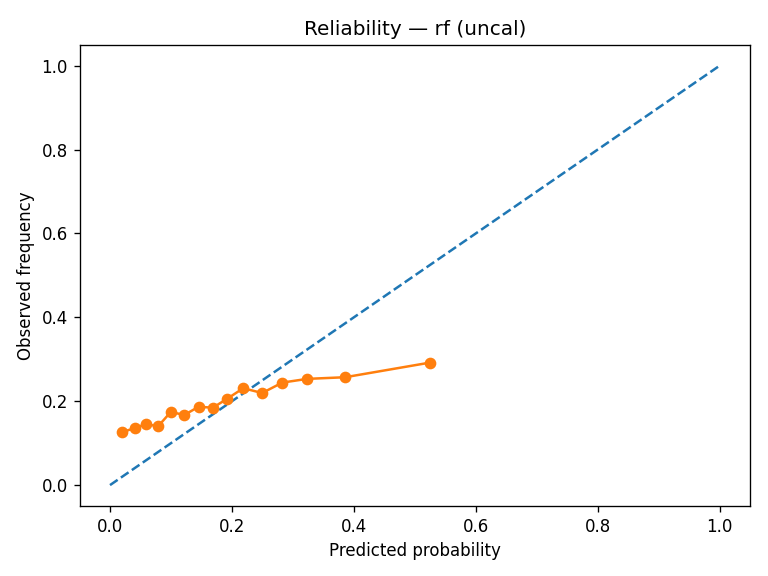

**PR — rf (cal)**

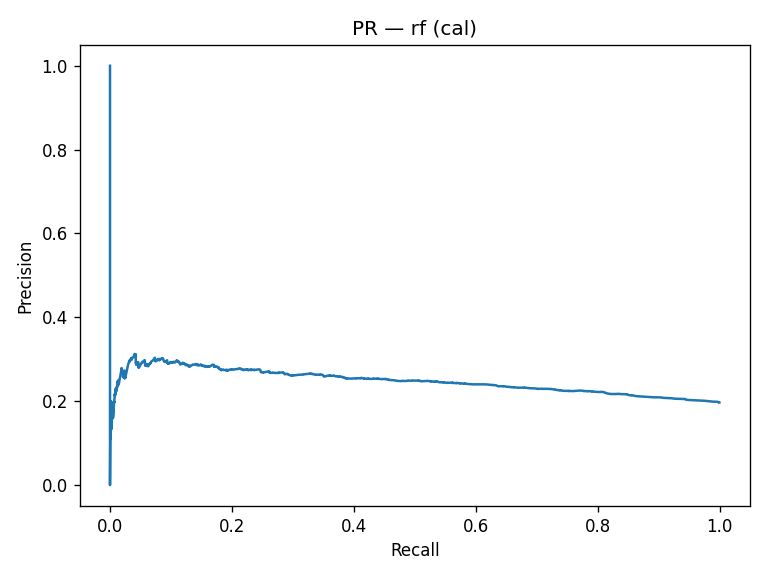

**Reliability — rf (cal)**

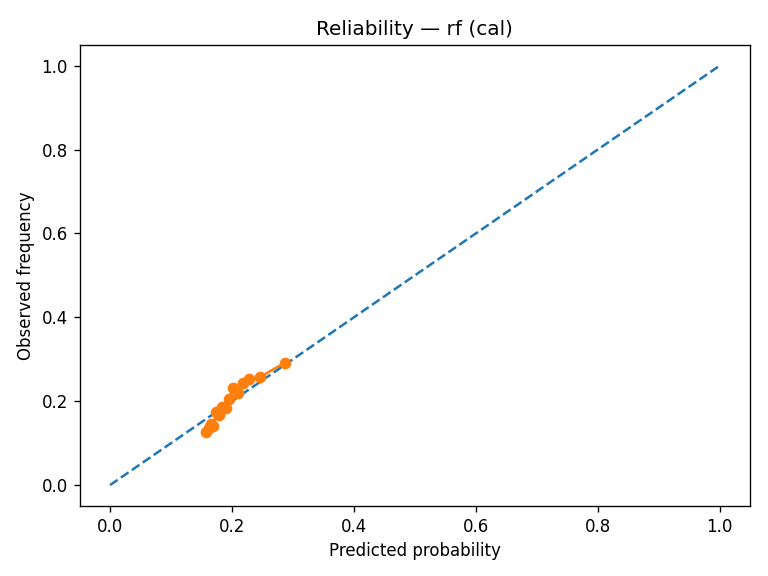

**PR — hgb (uncal)**

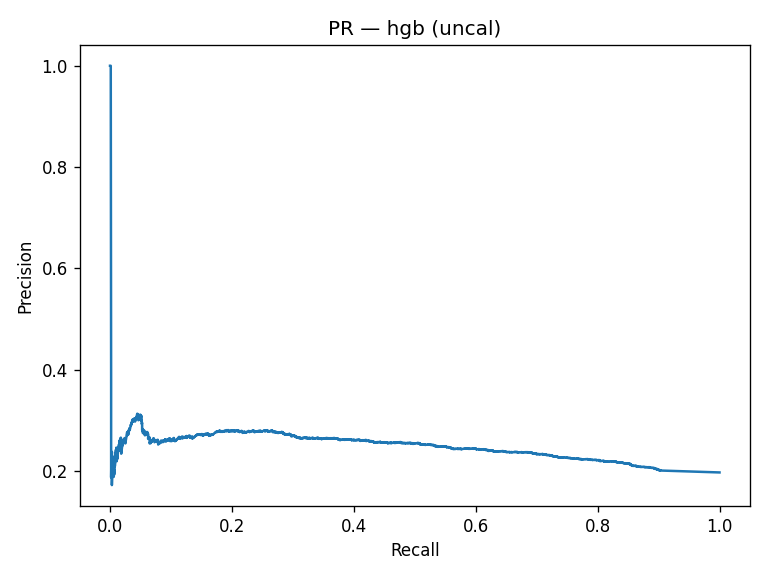

**Reliability — hgb (uncal)**

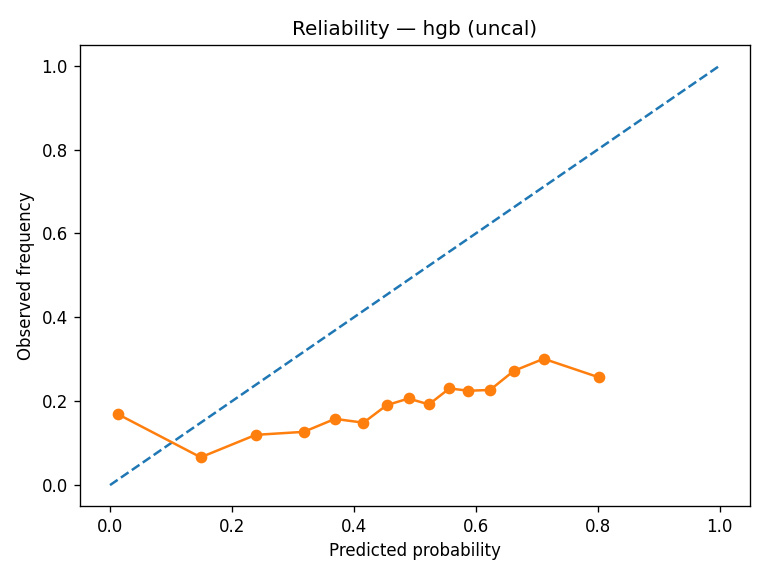

**PR — hgb (cal)**

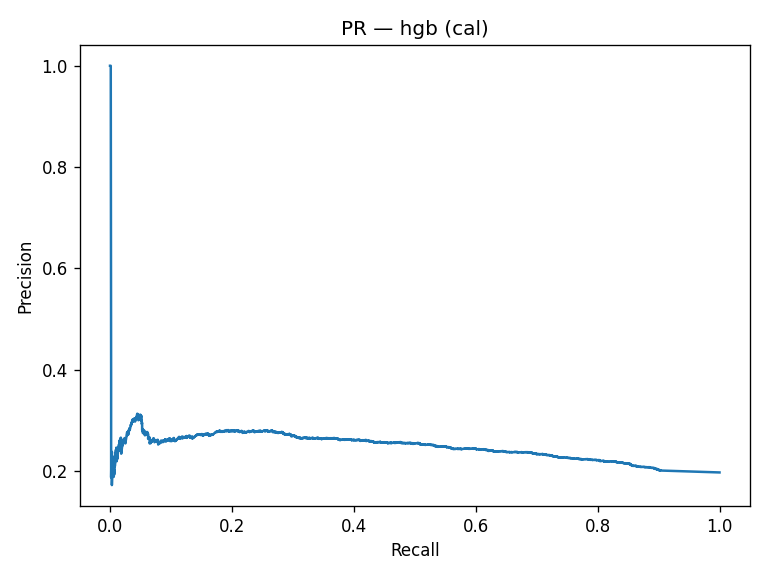

**Reliability — hgb (cal)**

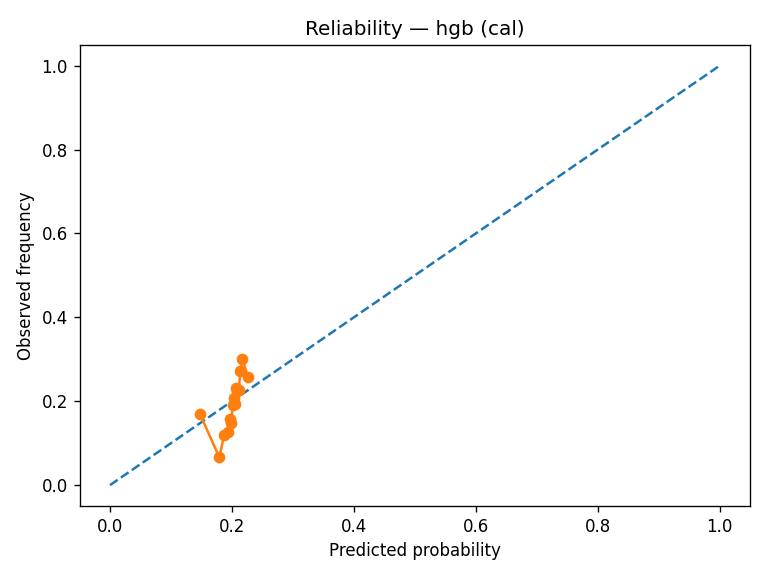

### Cost curves on VAL (FP:FN = 1.0:5.0)

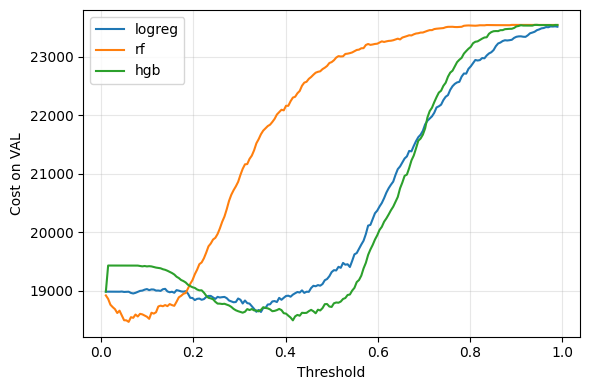

### Monthly backtest

**Regression backtest (Ridge)**

,Year,Month,n,RMSE,MAE,R2
0,2024,9,8604,9.692920,6.842181,0.962505
1,2024,10,8946,9.514453,6.732302,0.941034
2,2024,11,8205,10.010281,7.264235,0.961764
3,2024,12,8528,10.869335,7.585484,0.965673
4,2025,1,7703,11.420804,8.248708,0.958862
5,2025,2,7323,11.559506,8.341441,0.959290
6,2025,3,8668,11.231330,8.013269,0.963822
7,2025,4,8268,11.055559,7.744200,0.955534


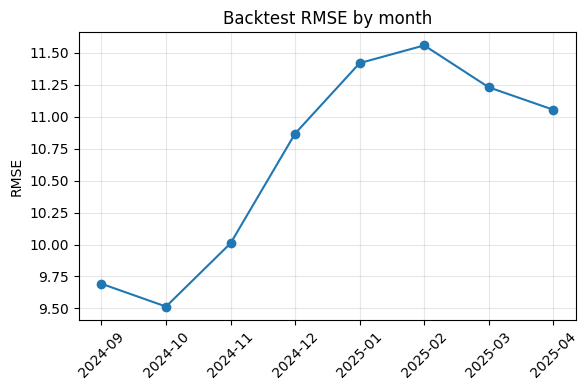

**Classification backtest (LR)**

,Year,Month,n,ROC_AUC,PR_AUC
0,2024,9,8673,0.738345,0.375879
1,2024,10,9044,0.740862,0.321619
2,2024,11,8261,0.734262,0.315006
3,2024,12,8608,0.737656,0.437829
4,2025,1,7703,0.547700,0.210980
5,2025,2,7323,0.557006,0.241137
6,2025,3,8668,0.574464,0.241503
7,2025,4,8268,0.582276,0.240663


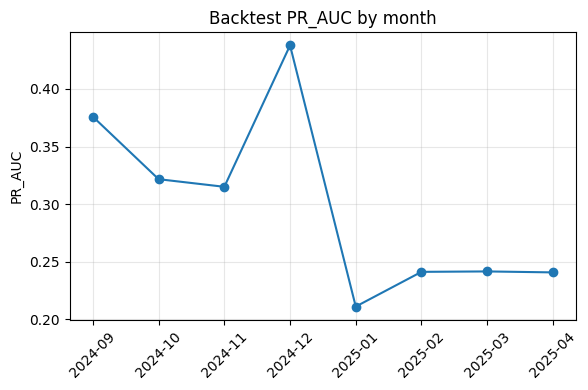

### Feature ablations

**Regression (Ridge)**

,task,removed,val_RMSE,test_RMSE,val_R2,test_R2
0,reg,(none),11.395163,11.055559,0.960917,0.955534
1,reg,CORE,11.435626,11.055184,0.960639,0.955537
2,reg,PROFILE,11.343266,10.996442,0.961272,0.956008
3,reg,ROLLING,11.397298,11.054486,0.960902,0.955543


**Classification (LR)**

,task,removed,val_ROC_AUC,test_ROC_AUC,val_PR_AUC,test_PR_AUC
0,clf,(none),0.560622,0.582276,0.230798,0.240663
1,clf,CORE,0.558331,0.576749,0.229583,0.237519
2,clf,PROFILE,0.598653,0.629168,0.259459,0.278187
3,clf,ROLLING,0.560610,0.582202,0.230774,0.240770


### Artifacts under ./bts_on_time_data/eda

,artifact,size_bytes,size_human
0,week4_ablation_clf.csv,412,412B
1,week4_ablation_reg.csv,394,394B
2,week4_backtest_clf.csv,433,433B
3,week4_backtest_reg.csv,569,569B
4,week4_clf_pr_hgb_cal.png,22739,22KB
5,week4_clf_pr_hgb_uncal.png,23034,22KB
6,week4_clf_pr_logreg_cal.png,25732,25KB
7,week4_clf_pr_logreg_uncal.png,25978,25KB
8,week4_clf_pr_rf_cal.png,23310,23KB
9,week4_clf_pr_rf_uncal.png,23573,23KB


In [3]:
# === Week4 Results Dashboard (Jupyter one-click) ===
from pathlib import Path
import json, numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import display, Image, Markdown

ROOT = Path("./bts_on_time_data")
EDA  = ROOT / "eda"

# ---------- helpers ----------
def confusion_at(y_true, y_prob, thr):
    y_pred = (y_prob >= thr).astype(int)
    tn = int(((y_true==0)&(y_pred==0)).sum())
    fp = int(((y_true==0)&(y_pred==1)).sum())
    fn = int(((y_true==1)&(y_pred==0)).sum())
    tp = int(((y_true==1)&(y_pred==1)).sum())
    return {"threshold": float(thr), "TP": tp, "FP": fp, "TN": tn, "FN": fn}

def prf(cm):
    tp, fp, tn, fn = cm["TP"], cm["FP"], cm["TN"], cm["FN"]
    prec = tp / max(tp+fp, 1)
    rec  = tp / max(tp+fn, 1)
    f1   = 0.0 if (prec+rec)==0 else 2*prec*rec/(prec+rec)
    return prec, rec, f1

def human_size(n):
    for u in ["B","KB","MB","GB"]:
        if n < 1024: return f"{n:.0f}{u}"
        n /= 1024
    return f"{n:.1f}TB"

# ---------- load metrics ----------
mfile = EDA/"week4_metrics.json"
assert mfile.exists(), f"Missing {mfile}"
metrics = json.load(open(mfile))

display(Markdown("## Week4 — Summary"))

# ---------- 1) Regression table ----------
rows = []
for mdl, pack in metrics["regression"].items():
    for split in ("val","test"):
        r = pack[split]
        rows.append([mdl, split, r["MAE"], r["RMSE"], r["R2"]])
reg_df = pd.DataFrame(rows, columns=["Model","Split","MAE","RMSE","R2"])
reg_df["MAE"]  = reg_df["MAE"].map(lambda x: f"{x:.3f}")
reg_df["RMSE"] = reg_df["RMSE"].map(lambda x: f"{x:.3f}")
reg_df["R2"]   = reg_df["R2"].map(lambda x: f"{x:.4f}")
display(Markdown("### Regression metrics"))
display(reg_df)

# ---------- 2) Classification metrics (uncal & cal) ----------
def tab_clf_uncal():
    rows=[]
    for mdl, pack in metrics["classification"].items():
        pv = pack["uncalibrated"]["val"]; pt = pack["uncalibrated"]["test"]
        rows.append([mdl,"val", pv["ROC_AUC"], pv["PR_AUC"], None, None, None])
        rows.append([mdl,"test", pt["ROC_AUC"], pt["PR_AUC"], pt.get("brier"),
                     pt.get("thr_cost"), pt.get("cost_test")])
    df = pd.DataFrame(rows, columns=["Model","Split","ROC_AUC","PR_AUC","Brier","Thr_cost","Cost@thr"])
    for c in ("ROC_AUC","PR_AUC","Brier","Thr_cost","Cost@thr"):
        df[c] = df[c].map(lambda x: None if x is None else f"{x:.3f}")
    return df

def tab_clf_cal():
    rows=[]
    for mdl, pack in metrics["classification"].items():
        if "calibrated" in pack:
            t = pack["calibrated"]["test"]
            rows.append([mdl, t["ROC_AUC"], t["PR_AUC"], t.get("brier")])
    if not rows: 
        return pd.DataFrame(columns=["Model","ROC_AUC","PR_AUC","Brier"])
    df = pd.DataFrame(rows, columns=["Model","ROC_AUC","PR_AUC","Brier"])
    for c in ("ROC_AUC","PR_AUC","Brier"):
        df[c] = df[c].map(lambda x: f"{x:.3f}")
    return df

display(Markdown("### Classification — Uncalibrated"))
display(tab_clf_uncal())
display(Markdown("### Classification — Calibrated (reported on TEST)"))
display(tab_clf_cal())

# ---------- 3) Confusion matrices (@0.5 & @cost-opt, UNCAL) ----------
def load_prob_csv(tag, cal=False):
    suffix = "cal" if cal else "uncal"
    pth = EDA/f"week4_clf_prob_{tag}_{suffix}.csv"
    df = pd.read_csv(pth)
    y = df["y_true"].astype(int).to_numpy()
    p = df["y_prob"].astype(float).to_numpy()
    return y, p

cm_rows=[]
for tag in ("logreg","rf","hgb"):
    y, p = load_prob_csv(tag, cal=False)
    cm05 = confusion_at(y, p, 0.5);   pr05, rc05, f105 = prf(cm05)
    thr_cost = metrics["classification"][tag]["uncalibrated"]["test"]["thr_cost"]
    cmc  = confusion_at(y, p, thr_cost); prc, rcc, f1c = prf(cmc)
    cm_rows.append([tag, "0.5",  cm05["TP"],cm05["FP"],cm05["TN"],cm05["FN"], f105, pr05, rc05])
    cm_rows.append([tag, f"{thr_cost:.3f}", cmc["TP"],cmc["FP"],cmc["TN"],cmc["FN"], f1c, prc, rcc])

cm_df = pd.DataFrame(cm_rows, columns=["Model","Thr","TP","FP","TN","FN","F1","Precision","Recall"])
for c in ("F1","Precision","Recall"):
    cm_df[c] = cm_df[c].map(lambda x: f"{x:.3f}")
display(Markdown("### Test confusion matrices (UNCAL)"))
display(cm_df)

# ---------- 4) PR curves & Reliability diagrams (embed images) ----------
def show_img(title, path):
    if Path(path).exists():
        display(Markdown(f"**{title}**"))
        display(Image(filename=str(path)))
    else:
        display(Markdown(f"- _missing_: {path}"))

display(Markdown("### PR curves & Reliability diagrams"))
for tag in ("logreg","rf","hgb"):
    show_img(f"PR — {tag} (uncal)", EDA/f"week4_clf_pr_{tag}_uncal.png")
    show_img(f"Reliability — {tag} (uncal)", EDA/f"week4_reliability_{tag}_uncal.png")
    show_img(f"PR — {tag} (cal)", EDA/f"week4_clf_pr_{tag}_cal.png")
    show_img(f"Reliability — {tag} (cal)", EDA/f"week4_reliability_{tag}_cal.png")

# ---------- 5) Cost curves (val) ----------
display(Markdown("### Cost curves on VAL (FP:FN = "
                 f"{metrics['costs']['FP_cost']}:{metrics['costs']['FN_cost']})"))
fig, ax = plt.subplots(figsize=(6,4))
for tag in ("logreg","rf","hgb"):
    f = EDA/f"week4_cost_curve_{tag}_val.csv"
    if f.exists():
        d = pd.read_csv(f)
        ax.plot(d["thr"], d["val_cost"], label=tag)
ax.set_xlabel("Threshold"); ax.set_ylabel("Cost on VAL")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# ---------- 6) Backtest curves ----------
bt_reg = EDA/"week4_backtest_reg.csv"
bt_clf = EDA/"week4_backtest_clf.csv"
if bt_reg.exists() or bt_clf.exists():
    display(Markdown("### Monthly backtest"))
if bt_reg.exists():
    d = pd.read_csv(bt_reg)
    display(Markdown("**Regression backtest (Ridge)**"))
    display(d)
    if {"Year","Month","RMSE"}.issubset(d.columns):
        d["YM"] = d["Year"].astype(int).astype(str) + "-" + d["Month"].astype(int).astype(str).str.zfill(2)
        plt.figure(figsize=(6,4)); plt.plot(d["YM"], d["RMSE"], marker="o"); 
        plt.xticks(rotation=45); plt.ylabel("RMSE"); plt.title("Backtest RMSE by month")
        plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()
if bt_clf.exists():
    d = pd.read_csv(bt_clf)
    display(Markdown("**Classification backtest (LR)**"))
    display(d)
    if {"Year","Month","PR_AUC"}.issubset(d.columns):
        d["YM"] = d["Year"].astype(int).astype(str) + "-" + d["Month"].astype(int).astype(str).str.zfill(2)
        plt.figure(figsize=(6,4)); plt.plot(d["YM"], d["PR_AUC"], marker="o"); 
        plt.xticks(rotation=45); plt.ylabel("PR_AUC"); plt.title("Backtest PR_AUC by month")
        plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

# ---------- 7) Ablation results ----------
abl_reg = EDA/"week4_ablation_reg.csv"
abl_clf = EDA/"week4_ablation_clf.csv"
if abl_reg.exists() or abl_clf.exists():
    display(Markdown("### Feature ablations"))
if abl_reg.exists():
    d = pd.read_csv(abl_reg); display(Markdown("**Regression (Ridge)**")); display(d)
if abl_clf.exists():
    d = pd.read_csv(abl_clf); display(Markdown("**Classification (LR)**")); display(d)

# ---------- 8) Artifacts & sizes ----------
arts = []
for p in sorted(EDA.glob("week4_*")):
    try: sz = p.stat().st_size
    except: sz = 0
    arts.append([p.name, sz, human_size(sz)])
art_df = pd.DataFrame(arts, columns=["artifact","size_bytes","size_human"])
display(Markdown("### Artifacts under ./bts_on_time_data/eda"))
display(art_df)